# **ARIMA Model, BTC - Martha McQuillan 1/14/2026**

In [2]:
import sys
from pathlib import Path

ROOT = Path().resolve().parents[0]
sys.path.append(str(ROOT))

In [3]:
from src.data_loader import load_prices_csv, compute_log_returns

prices = load_prices_csv("btc_eth_prices.csv")
returns = compute_log_returns(prices)

btc = returns["btc_usd_logret"]

I am deciding to set d=0 since the returns are already stationary, as depicted in the return graphs. Rather than performing an exhaustive grid search, the following focused set of low-order ARIMA models are chosen. The candidate set includes: a white noise baseline to test whether any time dependence is present at all, simple AR(1) and MA(1) specifications to capture short-horizon momentum and error effects, and a small number of higher-order models to assess whether modest additional flexibility improves performance without overfitting. 

This approach reflects common practice in financial time-series modeling, where returns typically exhibit weak short-memory dynamics and overly complex models tend to fit noise rather than signal.

In [4]:
candidates = [
    (0,0,0),
    (1,0,0),
    (0,0,1),
    (1,0,1),
    (2,0,1),
    (1,0,2),
    (2,0,2),
    (3,0,1),
]

In [5]:
from src.arima_model import evaluate_candidates

results = evaluate_candidates(btc, candidates)
results.sort_values("bic")

,p,d,q,aic,bic,lb_pvalue_10,lb_pvalue_20,converged
0,0,0,0,-11488.788524,-11476.818918,0.023611,0.101789,True
1,1,0,0,-11493.215014,-11475.260604,0.149873,0.351656,True
2,0,0,1,-11492.674461,-11474.720051,0.129916,0.322990,True
3,1,0,1,-11494.462110,-11470.522897,0.326101,0.545760,True
4,2,0,1,-11495.299507,-11465.375490,0.543962,0.712545,True
5,1,0,2,-11495.178502,-11465.254485,0.524142,0.703117,True
7,3,0,1,-11492.840481,-11456.931661,0.499347,0.681446,True
6,2,0,2,-11492.412880,-11456.504059,0.471764,0.657615,True


Based on the above statistics, we will drop ARIMA(0,0,0) since it fails the Ljung-Box test (p-value < .05) for LB(10), meaning that pure white noise misses some structure of the data. 

The data therefore support only very low-order ARIMA models, consistent with the high noise-to-signal ratio in crypto returns.

ARIMA(1,0,0), ARIMA(0,0,1), and ARIMA(1,0,1) were selected for out-of-sample evaluation, with final model choice based on rolling forecast error.

In [6]:
from src.backtest import rolling_backtest

finalists = [(1,0,0), (0,0,1), (1,0,1)]

for order in finalists:
    bt = rolling_backtest(btc, order, train_size=0.8, refit_every=7, maxiter=100)
    print(order, "MAE:", bt["mae"], "RMSE:", bt["rmse"], "N_test:", bt["n_test"])

(1, 0, 0) MAE: 0.016823717654662885 RMSE: 0.023334011815918185 N_test: 588
(0, 0, 1) MAE: 0.016825905459520164 RMSE: 0.023336724075081108 N_test: 588
(1, 0, 1) MAE: 0.01681643274817547 RMSE: 0.023317690977147337 N_test: 588


ARIMA(1,0,0) was selected for further analysis as it achieved the lowest out-of-sample RMSE among the candidate low-order models while maintaining comparable MAE, indicating slightly superior short-horizon forecasting performance without added model complexity.

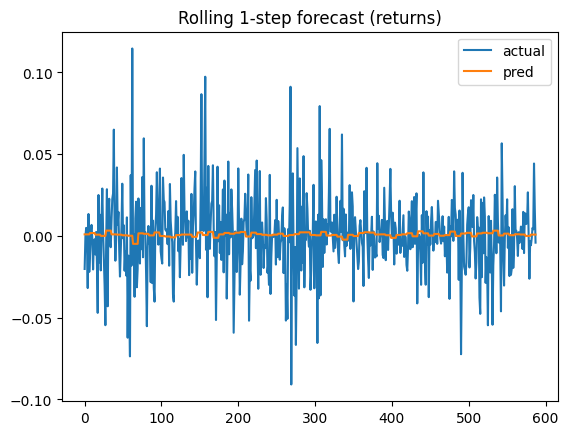

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

bt = rolling_backtest(btc, (1,0,0), refit_every=7)

actuals = pd.Series(bt["actuals"])
preds   = pd.Series(bt["preds"])

plt.figure()
actuals.plot(label="actual")
preds.plot(label="pred")
plt.title("Rolling 1-step forecast (returns)")
plt.legend()
plt.show()

This plot shows the rolling one-step-ahead ARIMA forecasts for daily log returns alongside the realized returns. As expected for liquid crypto assets, the realized returns exhibit high volatility and frequent large shocks, while the ARIMA forecasts remain tightly centered around zero.

This behavior reflects a well-known property of financial return series: while returns are approximately stationary, they contain limited short-horizon linear predictability. The model captures a small amount of serial dependence but does not attempt to forecast large return spikes, which are largely driven by exogenous information.

Importantly, the forecasts are stable over time and do not exhibit explosive behavior, indicating that the model is well-specified and not overfitting noise.

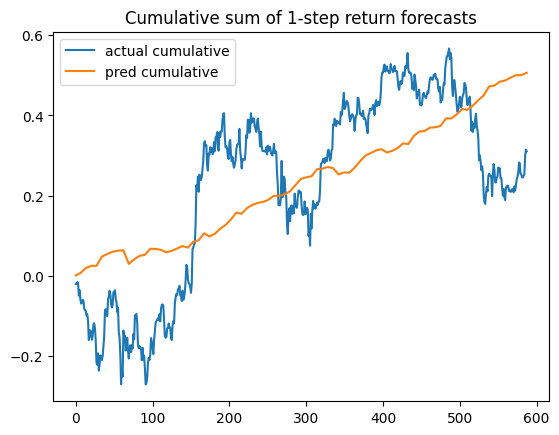

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

bt = rolling_backtest(btc, (1,0,0), refit_every=7)

actuals = pd.Series(bt["actuals"])
preds   = pd.Series(bt["preds"])

plt.figure()
actuals.cumsum().plot(label="actual cumulative")
preds.cumsum().plot(label="pred cumulative")
plt.title("Cumulative sum of 1-step return forecasts")
plt.legend()
plt.show()

To assess whether the ARIMA forecasts contain economically meaningful information, I examine the cumulative sum of realized returns and the cumulative sum of the model’s one-step-ahead forecasts.

The realized cumulative returns exhibit pronounced regime changes and drawdowns, reflecting the non-stationary nature of price levels. In contrast, the cumulative predicted returns form a smooth, slowly varying series. This indicates that the ARIMA model is capturing low-frequency directional bias rather than attempting to track short-term volatility.

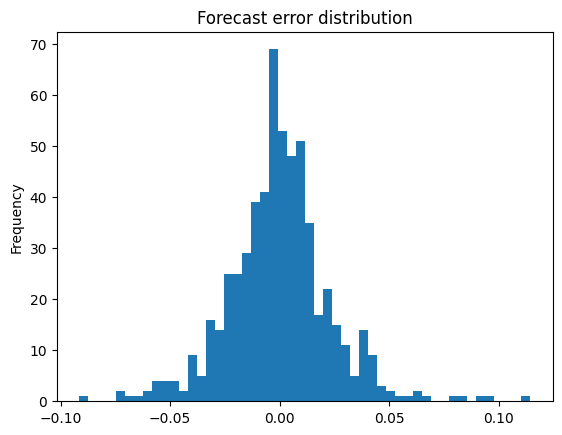

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

actuals = pd.Series(bt["actuals"])
preds   = pd.Series(bt["preds"])

err = actuals - preds

plt.figure()
err.plot(kind="hist", bins=50, title="Forecast error distribution")
plt.show()

The forecast error distribution is approximately symmetric and centered near zero, with moderately heavy tails. This indicates that the model’s forecasts are unbiased on average, but large errors occur during periods of elevated volatility.

### **Summary and Next Steps**

 - This analysis demonstrates that ARIMA models applied to daily crypto returns behave consistently with financial time-series theory. The models produce stable, unbiased forecasts but capture only weak short-horizon predictability, reflecting the near-efficient nature of liquid crypto markets.
 - Given the limited predictability in conditional mean returns, a more informative modeling direction is the conditional second moment (volatility), where I will pivot to in the next notebook.